In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle


In this notebook, we introduce a general structure for designing an ML-oriented project. In short, we will develop the flow depicted in the figure.

<img src="DALL·E 2025-01-26 18.46.20 - A simplified data science process flow diagram showing stages like raw data collection, preprocessing (handling missing data, feature selection), spli.webp" width="" align="" />

As raw data collection, we use the Telco Customer Churn dataset. This dataset is commonly used in machine learning tasks to predict customer churn behavior. The goal of the task is to develop a model that predicts whether a customer is likely to churn (i.e., stop doing business with the company) based on their usage patterns and account details.

The dataset contains information about telecom customers, including demographic details, account information, service usage patterns, and whether or not the customer has churned, which is the target variable in this task.

# DATA LOADING AND UNDERSTANDING

Used pd.read_csv() to load the Telco Customer Churn dataset from the specified CSV file path into a Pandas DataFrame called df. This method reads the CSV file and converts it into a tabular structure for analysis.

In [2]:
import pandas as pd

df=pd.read_csv("/work/WA_Fn-UseC_-Telco-Customer-Churn (1).csv")

The df.shape command was executed to display the number of rows and columns in the dataset. The output (7043, 21) indicates that the dataset contains 7043 rows (customers) and 21 columns (features).

In [3]:
df.shape

(7043, 21)

The df.head() command was used to display the first 5 rows of the dataset. This provides a quick overview of the data structure and the type of information each column contains.

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


This command is used to configure the Pandas display settings. By setting 'display.max_columns' to None, it ensures that all columns in the DataFrame are displayed when you view the data using commands like df.head() or df.info().

In [5]:
pd.set_option('display.max_columns', None)

In [6]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


df.head(): Provides a quick snapshot of the data to understand the structure and initial values.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


df.info(): Offers a detailed overview of the dataset, helping to identify missing values, column types, and the size of the dataset, which are critical for data preprocessing and feature engineering.

In [8]:
# Reloading the dataset because the previous 'df' variable is not accessible anymore.
import pandas as pd

df = pd.read_csv("/work/WA_Fn-UseC_-Telco-Customer-Churn (1).csv")

# Dropping customerID column as this is not required for modeling
df = df.drop(columns=["customerID"])

In [9]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
print(df["gender"].unique())


['Female' 'Male']


In [11]:
print(df["SeniorCitizen"].unique())

[0 1]


In [12]:
# Printing the unique values in all the columns except numerical features
numerical_features_list = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in df.columns:
    if col not in numerical_features_list:
        print(col, df[col].unique())
        print("-" * 50)


gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
--------------------------------------------------
TechSupport ['No' 'Yes' 'No internet service']
--------------------------------------------------
StreamingTV ['No' 'Yes' 'No internet 

In [13]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [14]:
df[df["TotalCharges"] == " "]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


It counts the number of rows where the column "TotalCharges" contains an empty string (" ").
This is necessary because some datasets store missing values as empty strings instead of NaN.

In [15]:
# Check the number of rows where 'TotalCharges' is an empty string
len(df[df["TotalCharges"] == ""])

0

Replaces all empty strings (" ") in "TotalCharges" with "0".
Prevents errors when converting this column to numeric type.

In [16]:
# Replace empty strings in 'TotalCharges' with "0"
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")

In [17]:
# Convert 'TotalCharges' to float
df["TotalCharges"] = df["TotalCharges"].astype(float)


Iterates through all columns in the dataset.Prints unique value counts for each column

Helps to understand the distribution of values in each column.
Useful for detecting anomalies, categorical features, or imbalanced classes.

In [18]:
# Loop through each column in the dataset and display value counts
for column in df.columns:
    print(df[column].value_counts())
    print('-' * 50)


gender
Male      3555
Female    3488
Name: count, dtype: int64
--------------------------------------------------
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
--------------------------------------------------
Partner
No     3641
Yes    3402
Name: count, dtype: int64
--------------------------------------------------
Dependents
No     4933
Yes    2110
Name: count, dtype: int64
--------------------------------------------------
tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64
--------------------------------------------------
PhoneService
Yes    6361
No      682
Name: count, dtype: int64
--------------------------------------------------
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64
--------------------------------------------------
InternetService
Fiber optic    3096
DSL            2421
No          

In [19]:
# Checking the class distribution of the target column
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


Insights:
Customer ID was removed as it is not required for modeling.
No missing values are present in the dataset.
Missing values in the TotalCharges column were replaced with 0.
Class imbalance is identified in the target column (Churn).

In [20]:

df.describe(include='all')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043.000000,7043
unique,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,NaN,2
top,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2279.734304,NaN
std,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.794470,NaN
min,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,0.000000,NaN
25%,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,398.550000,NaN
50%,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1394.550000,NaN
75%,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3786.600000,NaN


In [21]:
# Correcting the variable name
churn_counts = df["Churn"].value_counts()

# Display the result
print(churn_counts)

Churn
No     5174
Yes    1869
Name: count, dtype: int64


# EXPLORATORY DATA ANALYSIS(EDA)

In [22]:
df.shape

(7043, 20)

In [23]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [24]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [25]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


### Numerical Features-Analysis

understand the distribution of teh numerical features

In [26]:
def plot_histogram(df, column_name):
    plt.figure(figsize=(5, 3))
    sns.histplot(df[column_name], kde=True)
    plt.title(f"Distribution of {column_name}")
    
    # Calculate the mean and median values for the column
    col_mean = df[column_name].mean()
    col_median = df[column_name].median()
    
    # Add vertical lines for mean and median
    plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
    plt.axvline(col_median, color="green", linestyle="--", label="Median")
    
    plt.legend()
    plt.show()


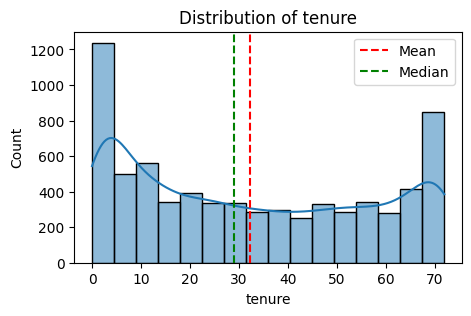

In [27]:
# The original error is "NameError: name 'sns' is not defined", which suggests that seaborn ("sns") is not imported. Let's fix it.

# Necessary imports
import matplotlib.pyplot as plt
import seaborn as sns

# Re-executing the plot_histogram call with the corrected column name
def plot_histogram(df, column_name):
    plt.figure(figsize=(5, 3))
    sns.histplot(df[column_name], kde=True)
    plt.title(f"Distribution of {column_name}")
    
    # Calculate the mean and median values for the column
    col_mean = df[column_name].mean()
    col_median = df[column_name].median()
    
    # Add vertical lines for mean and median
    plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
    plt.axvline(col_median, color="green", linestyle="--", label="Median")
    
    plt.legend()
    plt.show()

# Execute the function for "tenure"
plot_histogram(df, "tenure")

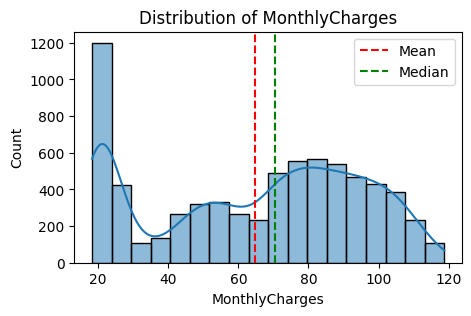

In [28]:
plot_histogram(df, "MonthlyCharges")

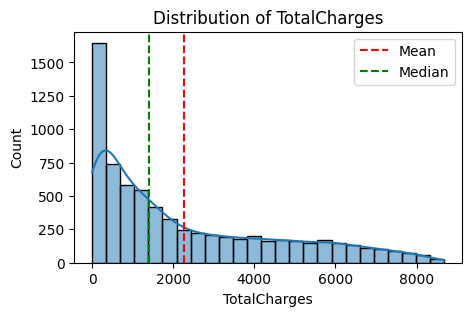

In [29]:
plot_histogram(df, "TotalCharges")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


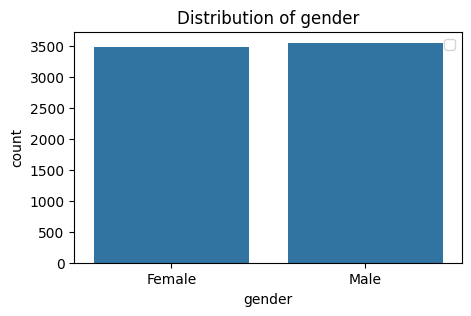

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_histogram(df, column_name):
    plt.figure(figsize=(5, 3))
    if df[column_name].dtype == "object":
        sns.countplot(x=df[column_name])
    else:
        sns.histplot(df[column_name], kde=True)
        
        col_mean = df[column_name].mean()
        col_median = df[column_name].median()
        
        plt.axvline(col_mean, color="red", linestyle="--", label="Mean")
        plt.axvline(col_median, color="green", linestyle="--", label="Median")

    plt.title(f"Distribution of {column_name}")
    plt.legend()  # Only works if a legend is available, check accordingly
    plt.show()

# Fixed invocation
plot_histogram(df, "gender")

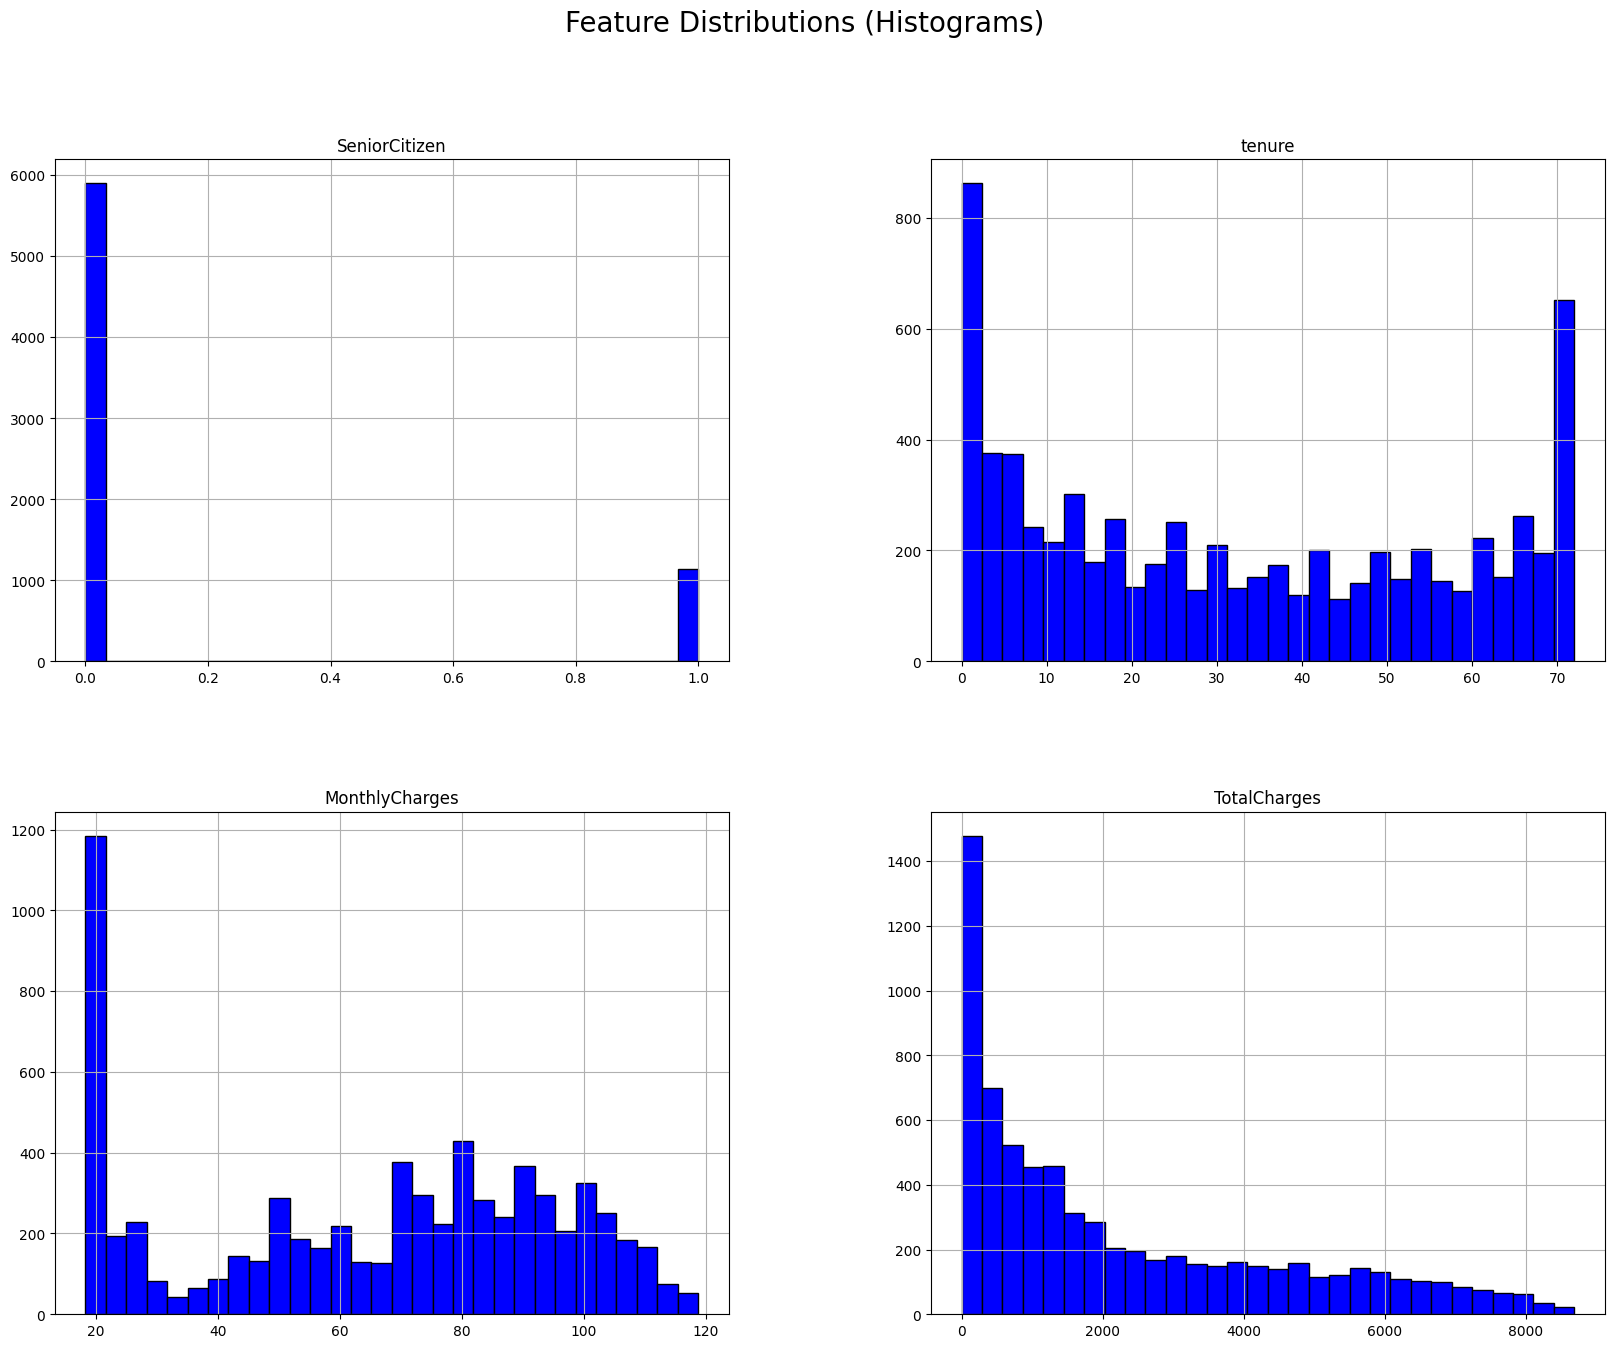

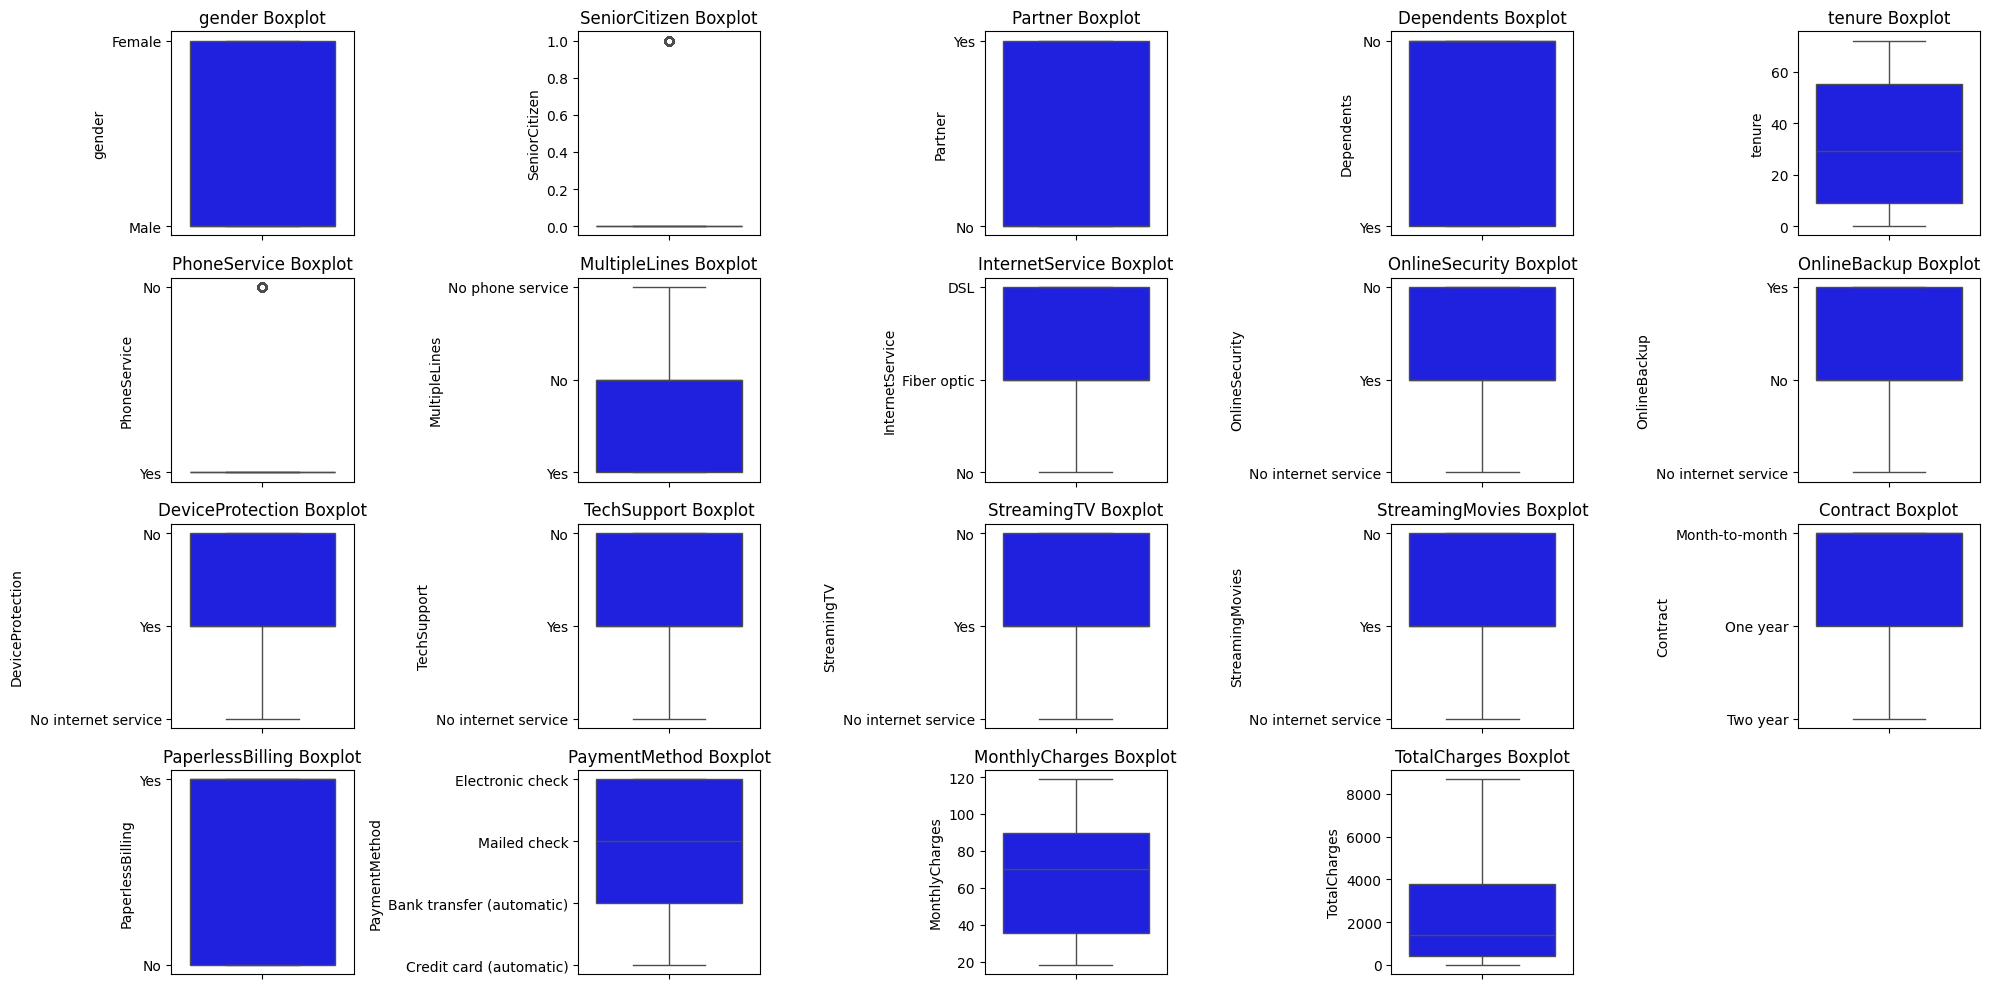

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reload the DataFrame since it appears to be undefined
df = pd.read_csv("/work/WA_Fn-UseC_-Telco-Customer-Churn (1).csv")

# Dropping customerID column as it is not required for modeling
df = df.drop(columns=["customerID"])

# Replace empty strings in 'TotalCharges' with "0"
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")

# Convert 'TotalCharges' to float
df["TotalCharges"] = df["TotalCharges"].astype(float)

# Define X by dropping the target variable ('Churn')
X = df.drop(columns=['Churn'])

# Plot histograms for all features
X.hist(bins=30, figsize=(20, 15), color='blue', edgecolor='black')
plt.suptitle('Feature Distributions (Histograms)', fontsize=20)
plt.show()

# Plot boxplots to visualize outliers
plt.figure(figsize=(20, 10))
# Iterate over all columns in X and create separate boxplots
for idx, column in enumerate(X.columns, 1):
    plt.subplot(4, 5, idx)  # Adjust subplot layout based on the number of features
    sns.boxplot(data=X[column], color='blue')
    plt.title(f"{column} Boxplot")
plt.tight_layout()
plt.show()

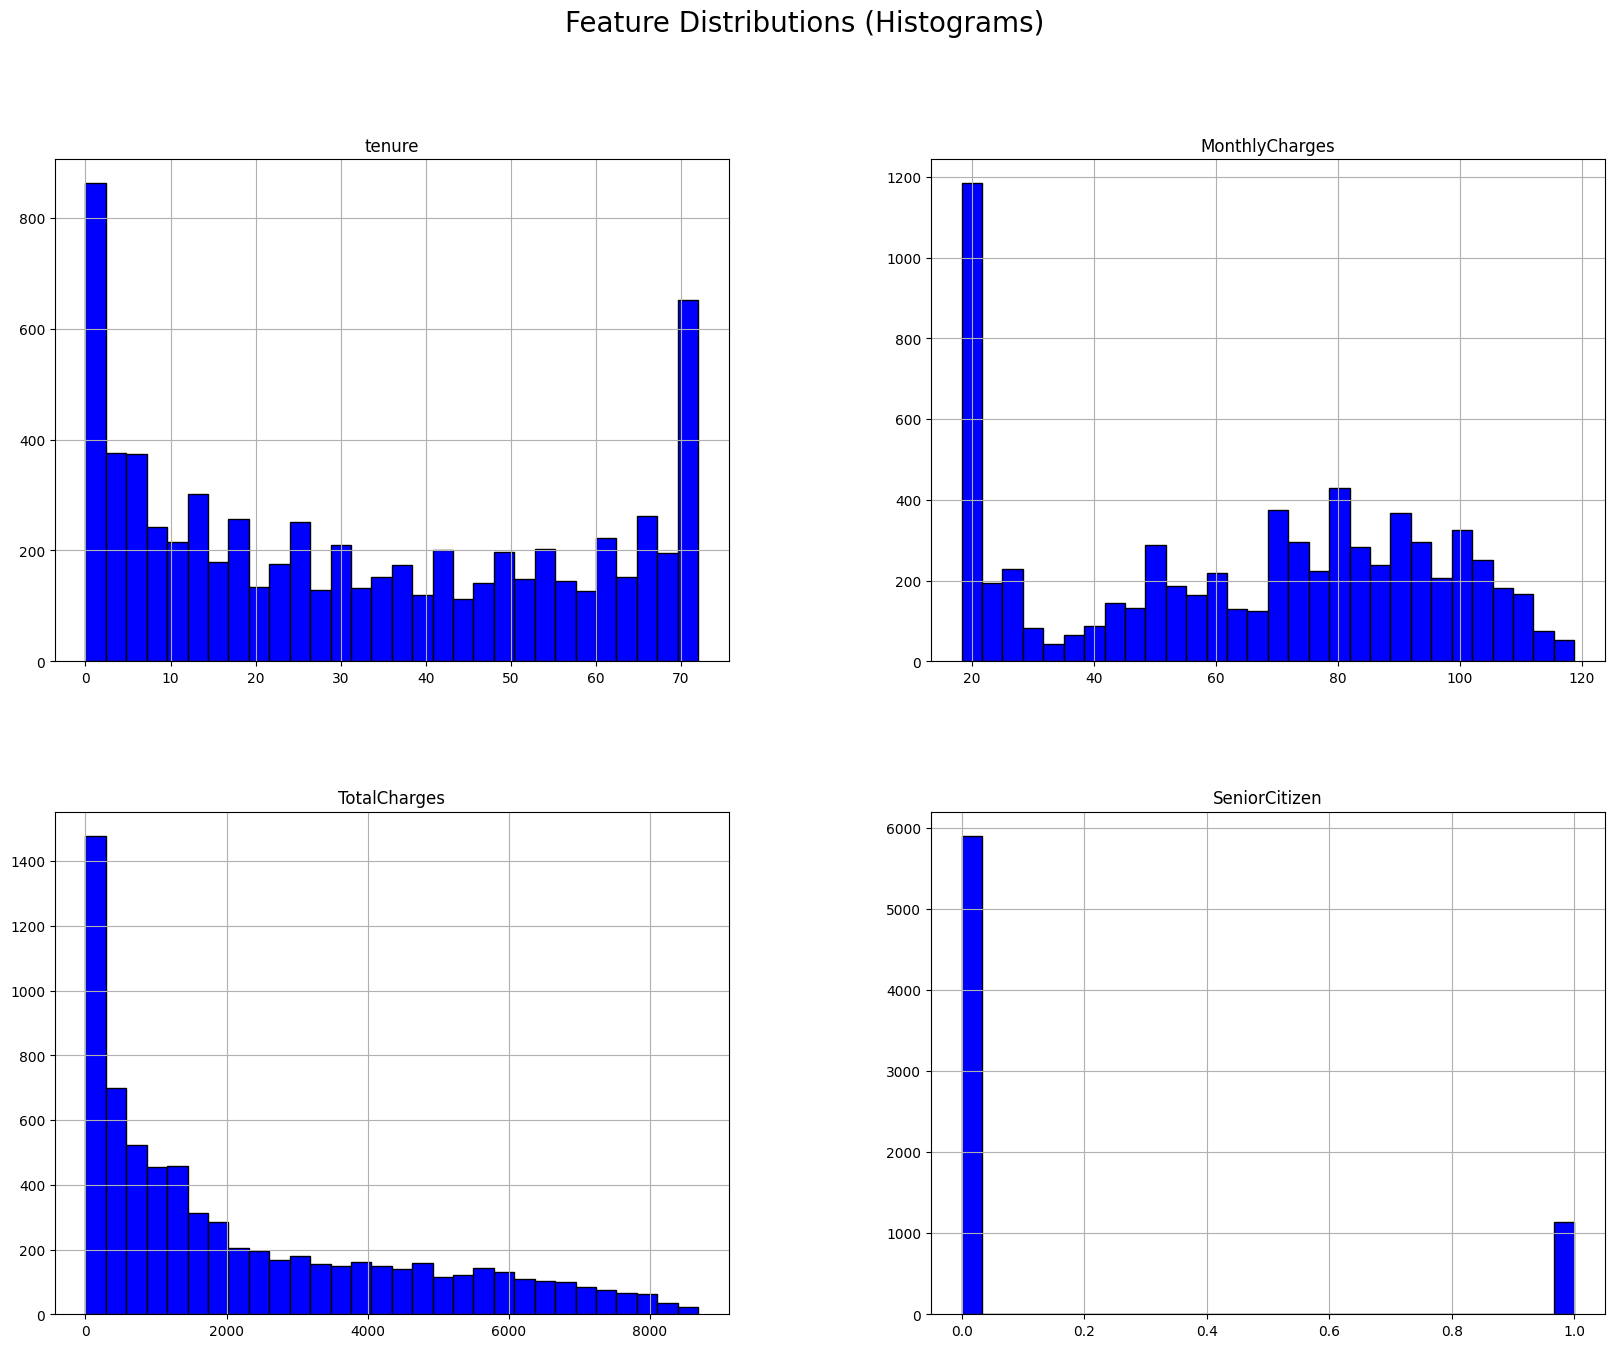

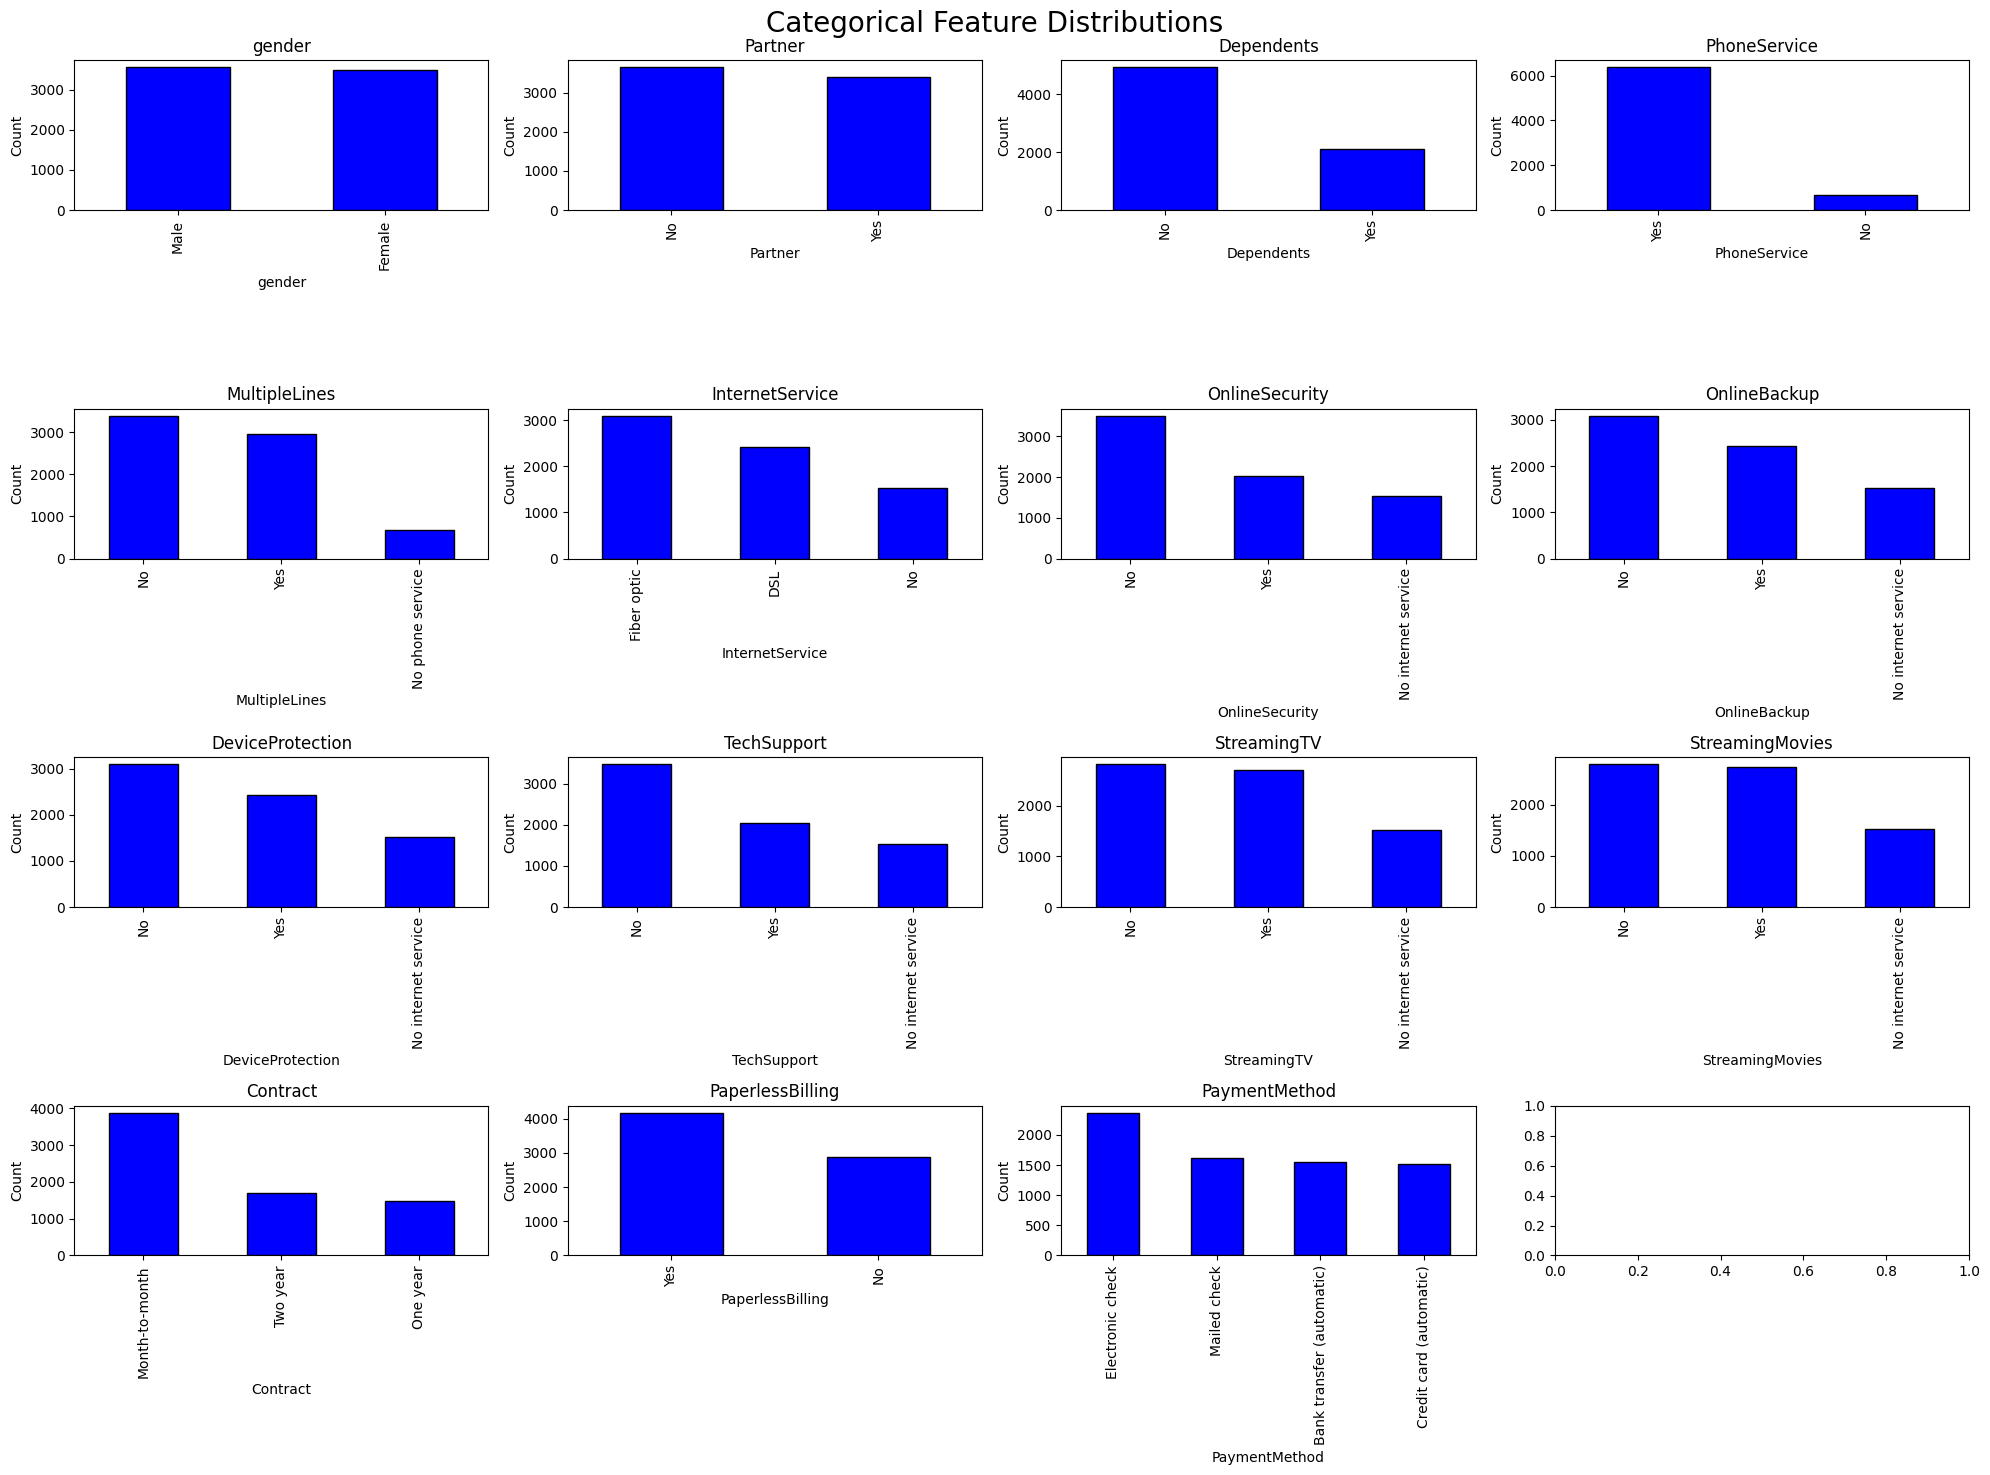

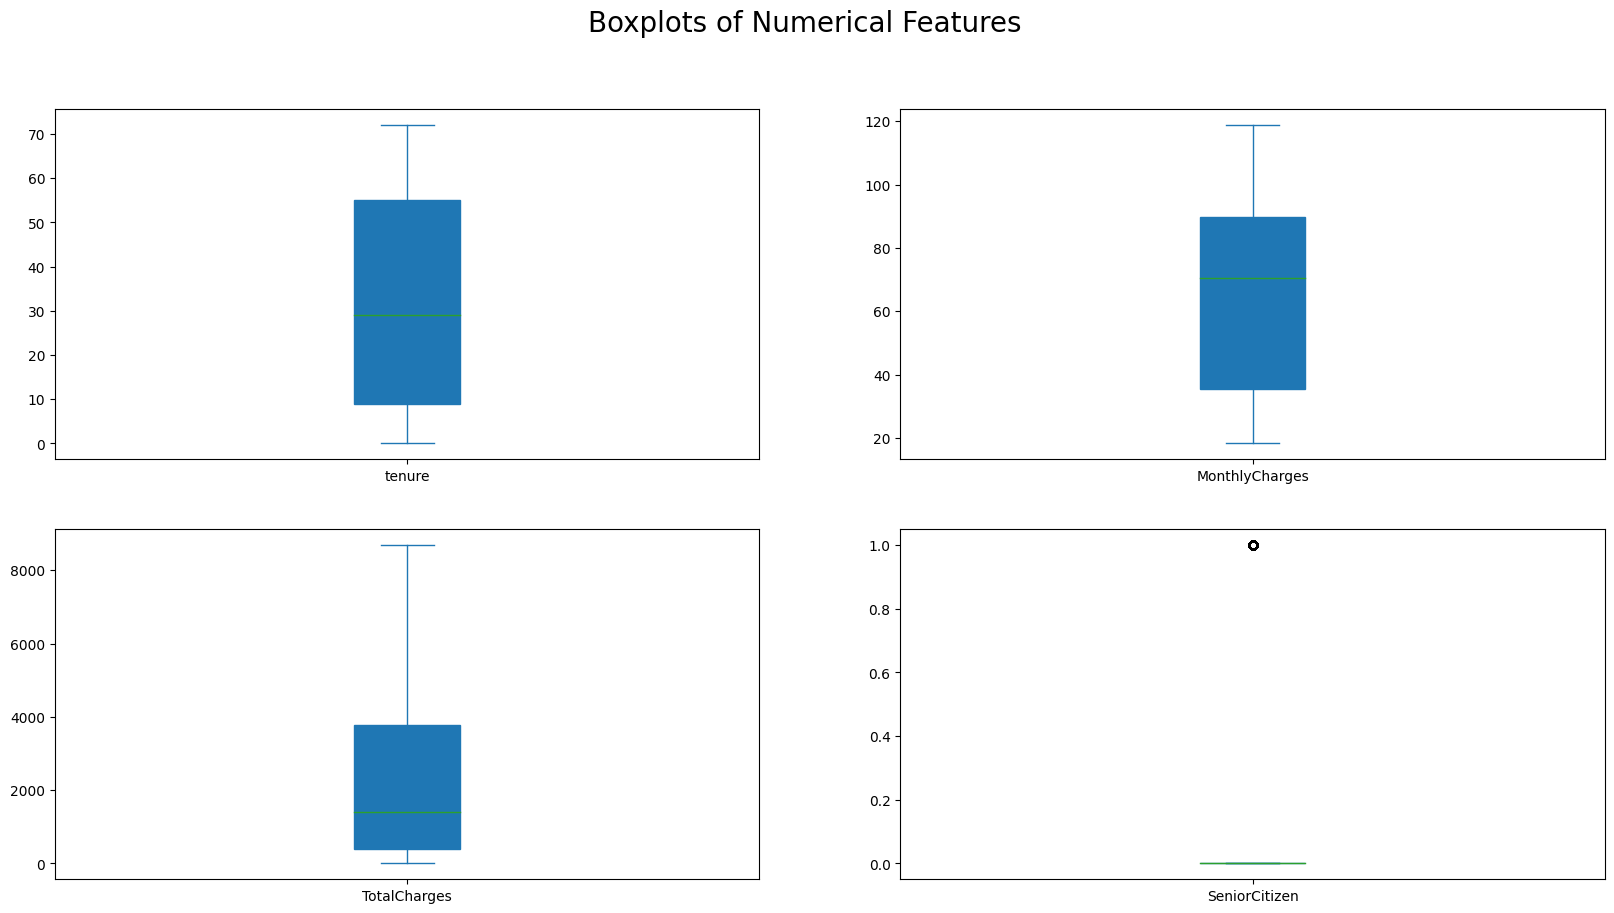

In [32]:
import matplotlib.pyplot as plt
import pandas as pd

# Separate numerical and categorical features
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
categorical_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                        'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                        'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
                        'PaymentMethod']

# Plot histograms for numerical features
X[numerical_features].hist(bins=30, figsize=(20, 15), color='blue', edgecolor='black')
plt.suptitle('Feature Distributions (Histograms)', fontsize=20)
plt.show()

# Plot bar plots for categorical features
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(20, 15))
fig.suptitle('Categorical Feature Distributions', fontsize=20)

for ax, feature in zip(axes.flatten(), categorical_features):
    X[feature].value_counts().plot(kind='bar', ax=ax, color='blue', edgecolor='black')
    ax.set_title(feature)
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

# Plot boxplots to visualize outliers for numerical features
X[numerical_features].plot(kind='box', subplots=True, layout=(2, 2), figsize=(20, 10), patch_artist=True)
plt.suptitle('Boxplots of Numerical Features', fontsize=20)
plt.show()


### Box plot for numerical features

A boxplot (also known as a whisker plot) is a graphical representation of the distribution of a dataset. It provides a summary of key statistical properties, including the central tendency, variability, and presence of outliers. Here's the outline of a boxplot and its components:

In [33]:
def plot_boxplot(df, column_name):
    plt.figure(figsize=(5, 3))
    sns.boxplot(y=df[column_name])
    plt.title(f"Distribution of {column_name}")
    plt.ylabel(column_name)
    plt.show()

Box (Interquartile Range, IQR):

The rectangular box represents the middle 50% of the data, known as the Interquartile Range (IQR).
The bottom of the box indicates the First Quartile (Q1) (25th percentile).
The top of the box indicates the Third Quartile (Q3) (75th percentile).
The length of the box (Q3 - Q1) represents the spread of the middle 50% of the data.

This function makes it easy to generate boxplots for any numerical column in a dataset. It uses Seaborn for visualization and Matplotlib for figure control.

Median Line:

A horizontal line inside the box represents the Median (50th percentile) of the data.
The median divides the dataset into two equal halves.

Whiskers:

The whiskers extend from the box to the smallest and largest data points within a defined range.
Whiskers usually cover data within 1.5 times the IQR from Q1 and Q3:
Lower whisker = Q1 - 1.5 * IQR
Upper whisker = Q3 + 1.5 * IQR

Outliers:

Outliers are data points that fall outside the whiskers (beyond 1.5 * IQR).
They are represented as individual dots or points on the plot.

Axis:

The y-axis (in vertical boxplots) or x-axis (in horizontal boxplots) corresponds to the range of values in the dataset.


<img src="boxplot-with-outliers.webp" width="" align="" />

<img src="boxplot4.jpg" width="" align="" />

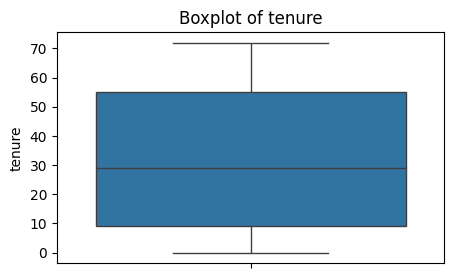

In [34]:
# Reloading the dataset since the 'df' variable is not defined anymore
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/work/WA_Fn-UseC_-Telco-Customer-Churn (1).csv")

# Dropping customerID column as it is not required for analysis
df = df.drop(columns=["customerID"])

# Defining the function to plot boxplots
def plot_boxplot(df, column_name):
    plt.figure(figsize=(5, 3))
    sns.boxplot(y=df[column_name])
    plt.title(f"Boxplot of {column_name}")
    plt.ylabel(column_name)
    plt.show()

# Plotting the boxplot for "tenure"
plot_boxplot(df, "tenure")

The plot_boxplot() function is called with the tenure column.
The resulting boxplot shows the distribution, median, and spread of the tenure variable (e.g., customer's duration in months).


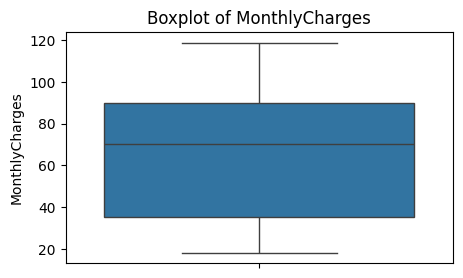

In [35]:
plot_boxplot(df, "MonthlyCharges")

Another call to plot_boxplot() is made, this time for the MonthlyCharges column.
The plot visualizes the distribution of customers' monthly charges, including the presence of any outliers.

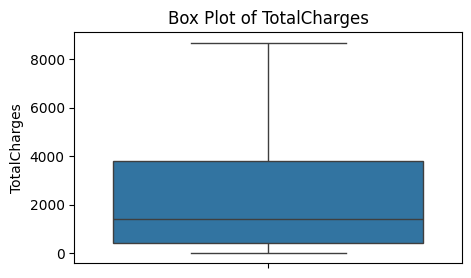

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset
df = pd.read_csv("/work/WA_Fn-UseC_-Telco-Customer-Churn (1).csv")

# Cleaning the TotalCharges column
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")  # Convert to numeric
df = df.dropna(subset=["TotalCharges"])  # Remove rows with missing TotalCharges

# Dropping customerID as it's not required
df = df.drop(columns=["customerID"])

# Defining the function to plot boxplots
def plot_boxplot(df, column_name):
    plt.figure(figsize=(5, 3))
    sns.boxplot(y=df[column_name])
    plt.title(f"Box Plot of {column_name}")
    plt.ylabel(column_name)
    plt.show()

# Plotting the boxplot for TotalCharges
plot_boxplot(df, "TotalCharges")


- Correlation Heatmap for numerical columns

A correlation matrix is simply a table that displays the correlation coefficients for different variables. The matrix depicts the correlation between all the possible pairs of values in a table. It is a powerful tool to summarize a large dataset and to identify and visualize patterns in the given data.

### A correlation matrix heatmap:

1.Data exploration to understand relationships between features.
2.Feature selection to identify highly correlated variables that might lead to redundancy.
3.Detecting multicollinearity in regression models.

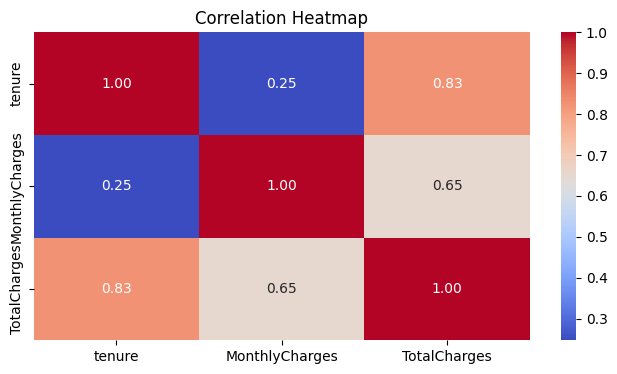

In [37]:
# Correlation matrix - heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

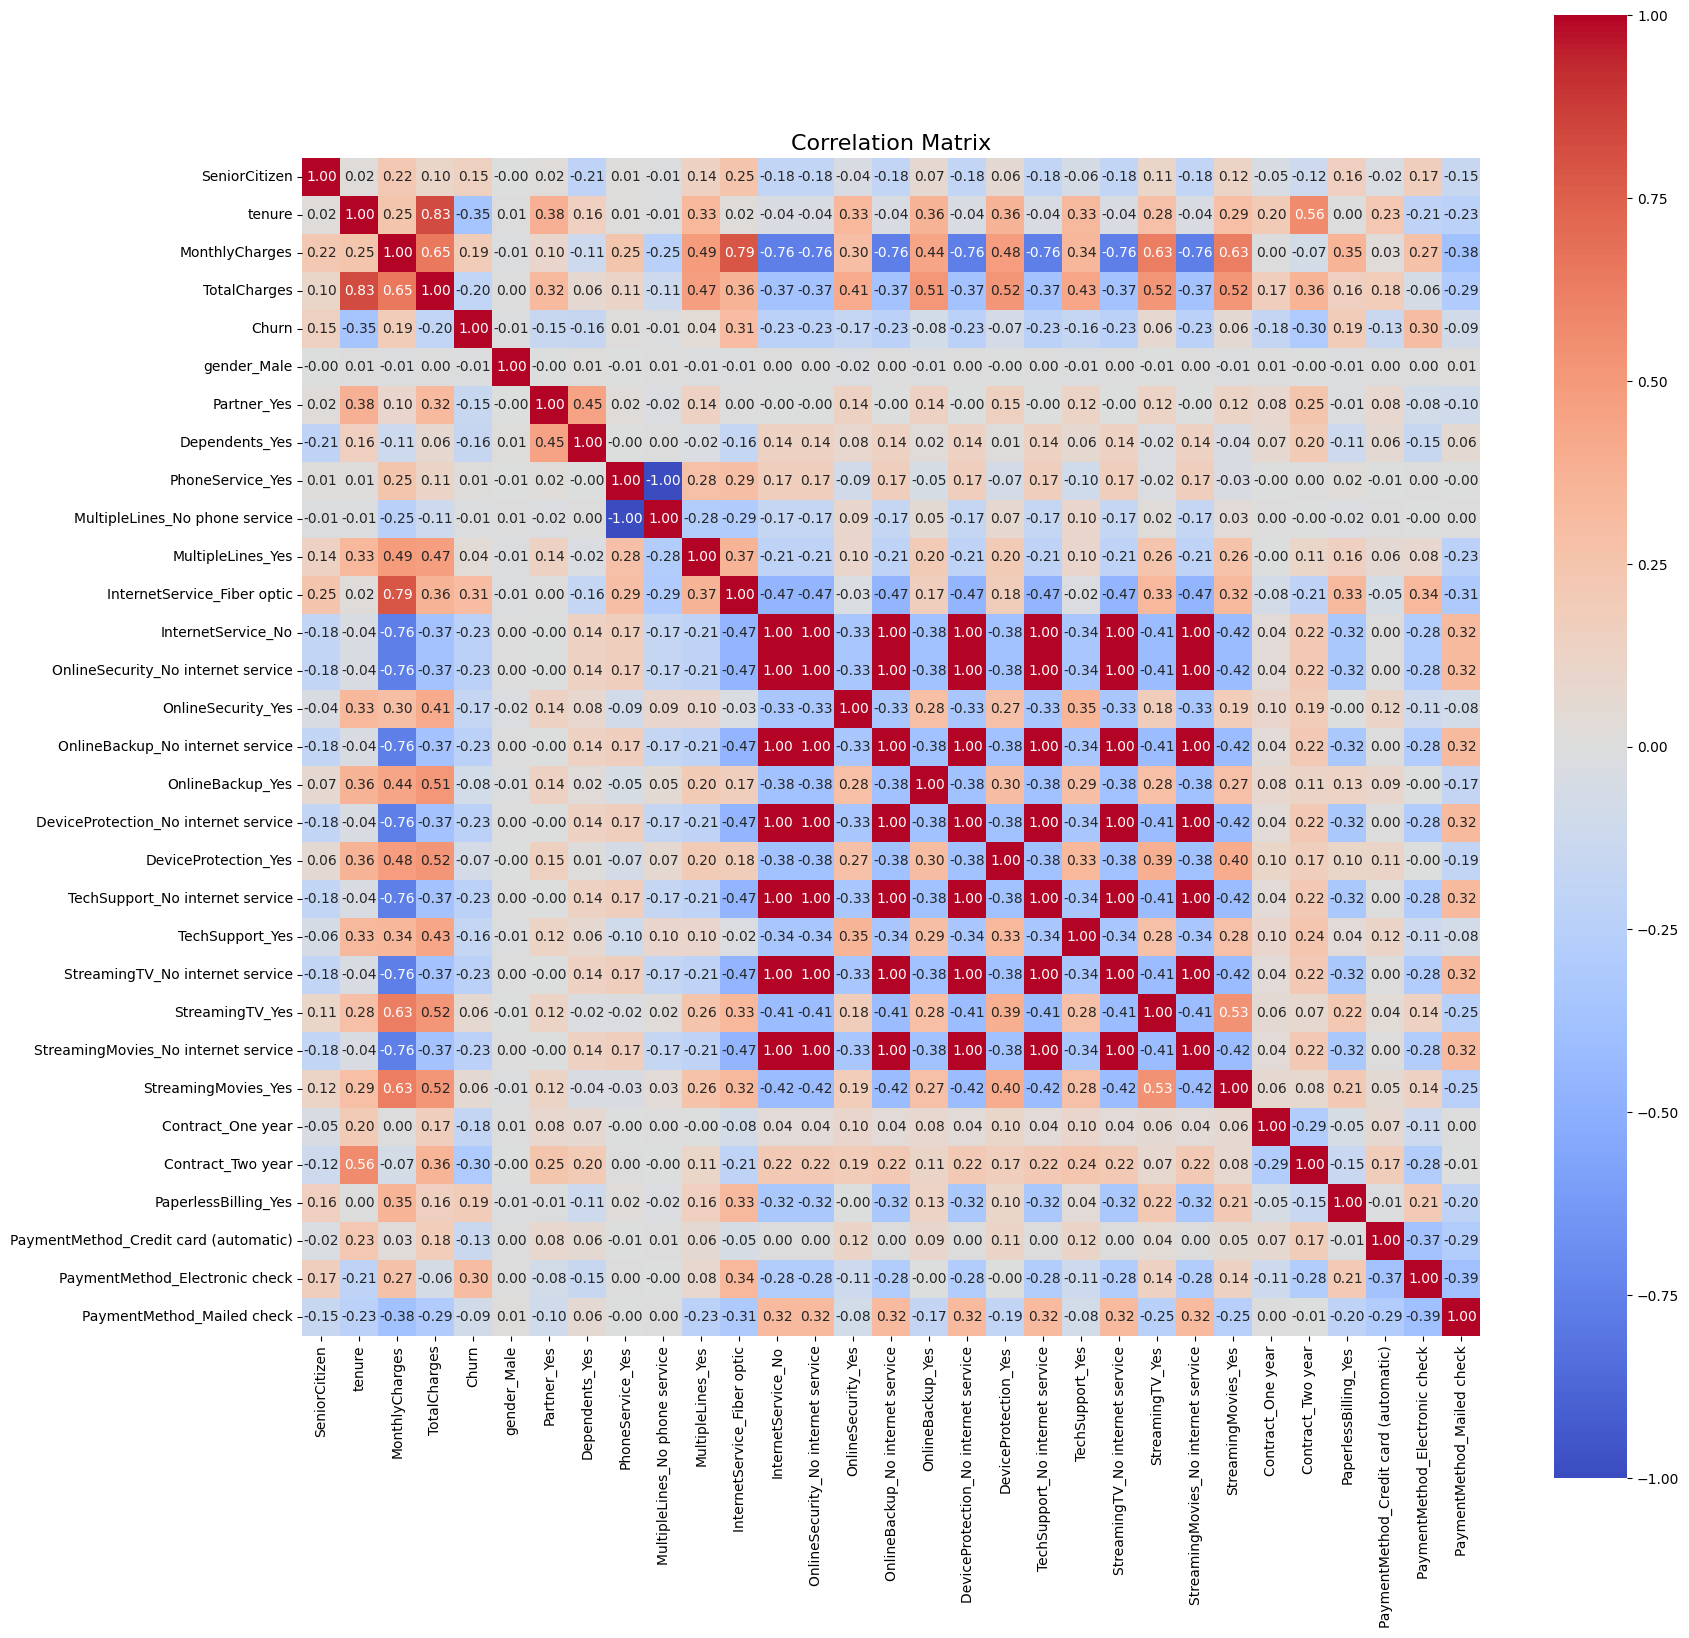

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Define dataset columns
columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
           'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
           'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
           'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
           'MonthlyCharges', 'TotalCharges', 'Churn']

# Load dataset (assuming df is already defined)
df = df[columns]

# Encode the categorical columns
label_encoder = LabelEncoder()
df['Churn'] = label_encoder.fit_transform(df['Churn'])

# Convert categorical variables to numeric
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 
                    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 
                    'PaperlessBilling', 'PaymentMethod']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Calculate the correlation matrix for all numerical features
corr_matrix = df.corr()

# Plot the heatmap
plt.figure(figsize=(19, 19))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True, square=True)
plt.title('Correlation Matrix', fontsize=16)
plt.show()

There are features that are STRONG correlated

Now Im going to Plot 4 of them to vissualize directly how much they are correlate.

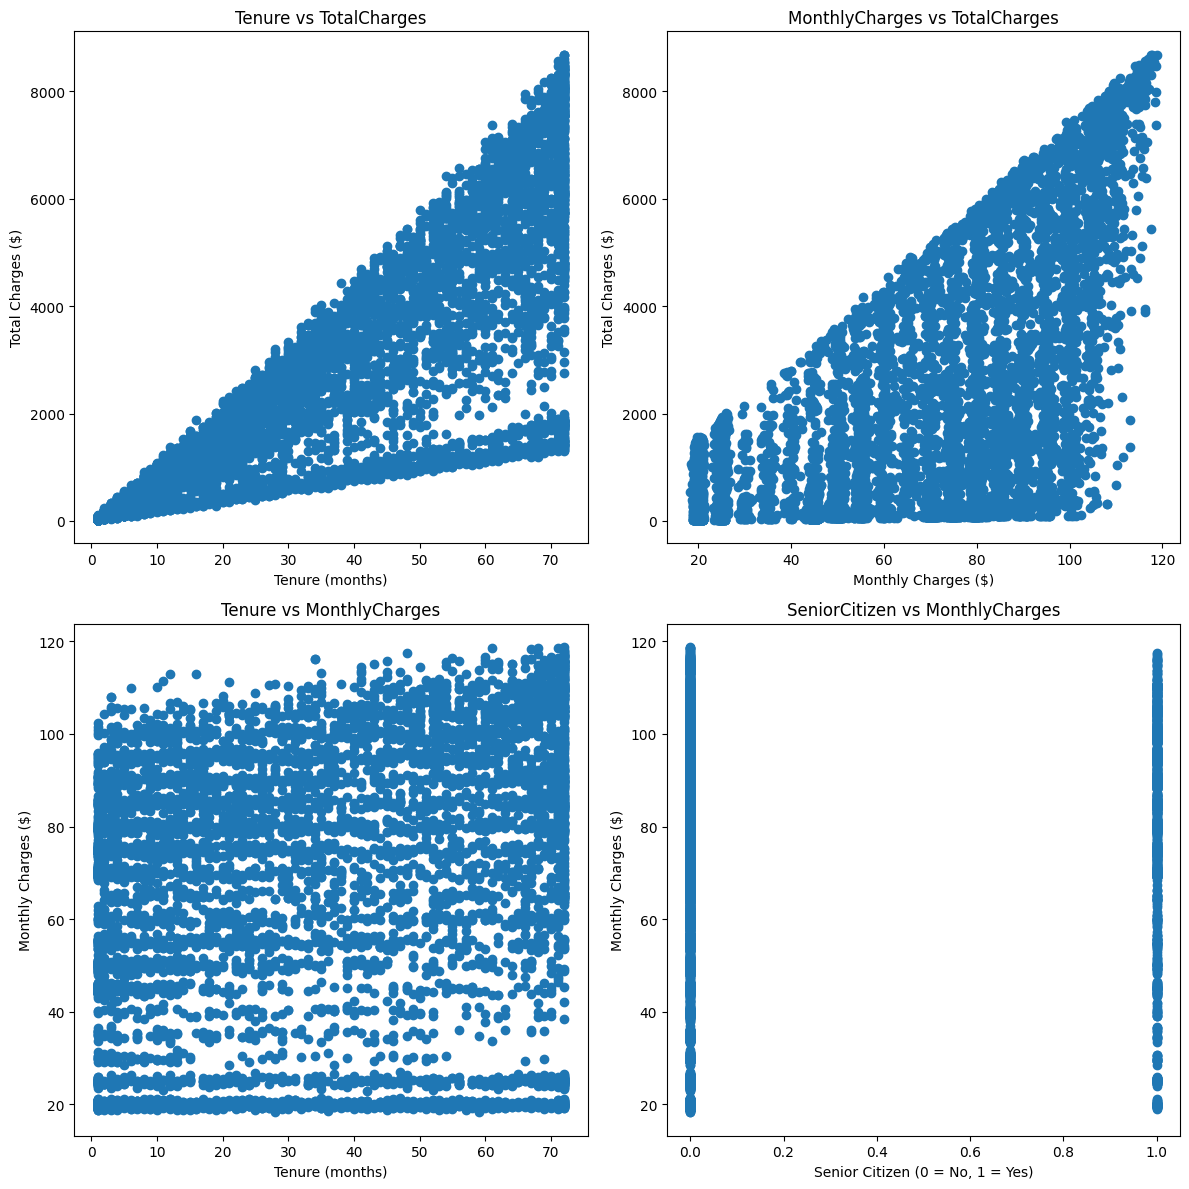

In [39]:
import matplotlib.pyplot as plt

# Create subplots with a grid layout (2 rows, 2 columns)
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Plot 1: Tenure vs TotalCharges
axes[0, 0].scatter(df['tenure'], df['TotalCharges'])
axes[0, 0].set_title('Tenure vs TotalCharges')
axes[0, 0].set_xlabel('Tenure (months)')
axes[0, 0].set_ylabel('Total Charges ($)')

# Plot 2: MonthlyCharges vs TotalCharges
axes[0, 1].scatter(df['MonthlyCharges'], df['TotalCharges'])
axes[0, 1].set_title('MonthlyCharges vs TotalCharges')
axes[0, 1].set_xlabel('Monthly Charges ($)')
axes[0, 1].set_ylabel('Total Charges ($)')

# Plot 3: Tenure vs MonthlyCharges
axes[1, 0].scatter(df['tenure'], df['MonthlyCharges'])
axes[1, 0].set_title('Tenure vs MonthlyCharges')
axes[1, 0].set_xlabel('Tenure (months)')
axes[1, 0].set_ylabel('Monthly Charges ($)')

# Plot 4: SeniorCitizen vs MonthlyCharges
axes[1, 1].scatter(df['SeniorCitizen'], df['MonthlyCharges'])
axes[1, 1].set_title('SeniorCitizen vs MonthlyCharges')
axes[1, 1].set_xlabel('Senior Citizen (0 = No, 1 = Yes)')
axes[1, 1].set_ylabel('Monthly Charges ($)')

# Adjust layout to make it look nice
plt.tight_layout()

# Show the combined plot
plt.show()



### Categorical features-Analysis

In [40]:
df.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   bool   
 6   Partner_Yes                            7032 non-null   bool   
 7   Dependents_Yes                         7032 non-null   bool   
 8   PhoneService_Yes                       7032 non-null   bool   
 9   MultipleLines_No phone service         7032 non-null   bool   
 10  MultipleLines_Yes                      7032 non-null   bool   
 11  InternetS

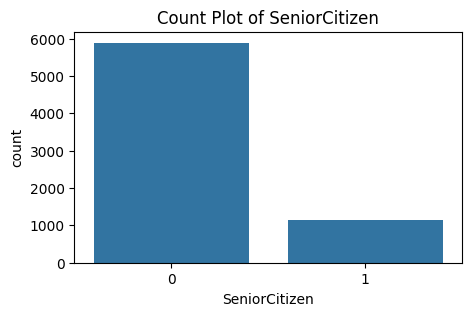

In [42]:
# Select columns with data type 'object'
object_cols = df.select_dtypes(include="object").columns.to_list()

# Add a specific column to the list of object columns
object_cols = ["SeniorCitizen"] + object_cols

# Plot count plots for each object column
for col in object_cols:
    plt.figure(figsize=(5, 3))  # Set figure size
    sns.countplot(x=df[col])  # Create a count plot for the column
    plt.title(f"Count Plot of {col}")  # Set the plot title
    plt.show()  # Display the plot



# INTRODUCING NOISE AND UNBALANCED DATA

# EXPLORING THE DATASET

# DATA PREPROCESSING

In [43]:
df.head(3)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True


In [44]:
# Correcting the file path to the correct dataset location
df = pd.read_csv("/work/WA_Fn-UseC_-Telco-Customer-Churn (1).csv")

# Replace "Yes" and "No" with 1 and 0 in the 'Churn' column
df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})

# Check dataset shape and value counts
print("Dataset shape:", df.shape)
print("Missing values in 'Churn':", df["Churn"].isnull().sum())
print(df["Churn"].value_counts())

Dataset shape: (7043, 21)
Missing values in 'Churn': 0
Churn
0    5174
1    1869
Name: count, dtype: int64


### Label encoding of categorical features 

In [45]:
import pandas as pd

# Load your data (replace 'data.csv' with your file path)
df = pd.read_csv('/work/WA_Fn-UseC_-Telco-Customer-Churn (1).csv')

# Now select object-type columns
object_columns = df.select_dtypes(include="object").columns

In [46]:

print(object_columns)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


In [47]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import pickle

# Initialize a dictionary to save the encoders
encoders = {}

# Apply label encoding and store the encoders
for column in object_columns:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder

# Save the encoders to a pickle file
with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [48]:
encoders

{'customerID': LabelEncoder(),
 'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder(),
 'TotalCharges': LabelEncoder(),
 'Churn': LabelEncoder()}

This script performs One-Hot Encoding on categorical variables in the Telco Customer Churn dataset, ensuring that both training (X_train) and testing (X_test) datasets have consistent feature structures for machine learning models.Machine Learning models require numerical input, so categorical features must be converted into numerical format.

In [49]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(columns=['Churn'])
y = df['Churn']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print feature types
print("Feature Data Types:\n", X_train.dtypes)
 # Check data types to identify categorical features


Feature Data Types:
 customerID            int64
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges          int64
dtype: object


In [50]:
#  Apply One-Hot Encoding
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)


Ensures feature consistency between training and testing sets, preventing model errors.

In [51]:
#  Ensure X_train and X_test have the same columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [52]:
print("Data after One-Hot Encoding:")
print(X_train.head())

Data after One-Hot Encoding:
      customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
2142        2956       0              0        0           1      21   
1623        4287       0              0        0           0      54   
6074        2674       1              0        1           0       1   
1362        1756       1              0        0           0       4   
6754        1906       1              0        0           1       0   

      PhoneService  MultipleLines  InternetService  OnlineSecurity  \
2142             1              0                0               2   
1623             1              2                1               0   
6074             0              1                0               0   
1362             1              0                1               0   
6754             1              2                0               2   

      OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
2142             0                 2            0  

# Training and data split

In [53]:
# Splitting the features and target
X = df.drop(columns=['Churn'])  # Correct syntax for dropping columns
y = df['Churn']

In [54]:
print(X)

      customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0           5375       0              0        1           0       1   
1           3962       1              0        0           0      34   
2           2564       1              0        0           0       2   
3           5535       1              0        0           0      45   
4           6511       0              0        0           0       2   
...          ...     ...            ...      ...         ...     ...   
7038        4853       1              0        1           1      24   
7039        1525       0              0        1           1      72   
7040        3367       0              0        1           1      11   
7041        5934       1              1        1           0       4   
7042        2226       1              0        0           0      66   

      PhoneService  MultipleLines  InternetService  OnlineSecurity  \
0                0              1                0               

In [55]:

# Split training and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
print(y_train.shape)

(5634,)


In [57]:
print(y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


- Synthetic Minority Oversampling Technique(SMOTE

In [58]:
smote = SMOTE(random_state=42)

In [59]:
# Apply SMOTE to the training data
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [60]:
# Check the shape of the resampled target variable
print(y_train_smote.shape)

(8276,)


In [61]:
# Check the class distribution after applying SMOTE
print(y_train_smote.value_counts())

Churn
0    4138
1    4138
Name: count, dtype: int64


# 

Training with default hyperparameters

In [62]:
# Dictionary of models
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [63]:
# Dictionary to store the cross-validation results
cv_scores = {}

# Perform 5-fold cross-validation for each model
for model_name, model in models.items():
    print(f"Training {model_name} with default parameters")
    scores = cross_val_score(model, X_train_smote, y_train_smote, cv=5, scoring="accuracy")
    cv_scores[model_name] = scores
    print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f}")
    print("-" * 70)

Training Decision Tree with default parameters
Decision Tree cross-validation accuracy: 0.78
----------------------------------------------------------------------
Training Random Forest with default parameters
Random Forest cross-validation accuracy: 0.84
----------------------------------------------------------------------
Training XGBoost with default parameters
XGBoost cross-validation accuracy: 0.84
----------------------------------------------------------------------


In [64]:
cv_scores

{'Decision Tree': array([0.66727053, 0.70574018, 0.83806647, 0.83444109, 0.83685801]),
 'Random Forest': array([0.71618357, 0.75347432, 0.90574018, 0.90271903, 0.91299094]),
 'XGBoost': array([0.70350242, 0.7407855 , 0.91178248, 0.9021148 , 0.91963746])}

Random Forest gives the highest accuracy compared to other models with default parameters

In [65]:
# Initialize the RandomForestClassifier
rfc = RandomForestClassifier(random_state=42)


In [66]:
model.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...)

In [67]:
print(y_test.value_counts())

Churn
0    1036
1     373
Name: count, dtype: int64


# 

In [68]:
# Make predictions on the test data
y_test_pred = model.predict(X_test)  # Use X_test, not y_test

# Evaluate the model
print("Accuracy Score:", accuracy_score(y_test, y_test_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Accuracy Score: 0.7828246983676366
Confusion Matrix:
 [[886 150]
 [156 217]]
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.86      0.85      1036
           1       0.59      0.58      0.59       373

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [69]:
# Save the trained model and feature names as a pickle file
model_data = {"model": rfc, "feature_names": X.columns.tolist()}

with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

In [70]:
# Load the saved model and feature names
with open("customer_churn_model.pkl", "rb") as f:
    model_data = pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["feature_names"]

In [71]:
print(loaded_model)

RandomForestClassifier(random_state=42)


In [72]:
print(feature_names)

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [73]:
    encoders

{'customerID': LabelEncoder(),
 'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder(),
 'TotalCharges': LabelEncoder(),
 'Churn': LabelEncoder()}

we create missing data

In [74]:
def add_missing_columns(df, columns):
    X = col.copy()
    size = amount if amount >= 1 else int(len(X) * amount)
    indexes = np.nan
    return X


#     
def add_missing_rows(df, amount):
    X = df.copy()
    rows, cols = X.shape
    size = amount if amount >=1 else int(rows * amount)
    indexes = np.random.choice(rows, size, replace=False) + 0.5
    for i in indexes:
        X.loc[i] = np.full((cols,), np.nan)
    X = X.sort_index().reset_index(drop=True)
    return X




In [75]:
import numpy as np
import pandas as pd

def add_missing_columns(df, columns, amount=0.1):
    X = df.copy()
    for col in columns:
        size = amount if amount >= 1 else int(len(X) * amount)
        missing_indices = np.random.choice(X.index, size, replace=False)
        X.loc[missing_indices, col] = np.nan
    return X

def add_missing_rows(df, amount=0.1):
    X = df.copy()
    rows, cols = X.shape
    size = amount if amount >= 1 else int(rows * amount)
    missing_indices = np.random.choice(X.index, size, replace=False)
    for i in missing_indices:
        X.loc[i] = np.nan  # Replace the entire row with NaN
    X = X.sort_index().reset_index(drop=True)
    return X

# Example dataset
dataset = pd.DataFrame({
    "gender": np.random.choice(["Male", "Female"], 100),
    "senior_citizen": np.random.choice([0, 1], 100),
    "partner": np.random.choice(["Yes", "No"], 100),
    "dependents": np.random.choice(["Yes", "No"], 100),
    "phone_service": np.random.choice(["Yes", "No"], 100),
    "multiple_lines": np.random.choice(["Yes", "No"], 100),
    "internet_service": np.random.choice(["DSL", "Fiber optic", "No"], 100),
    "online_security": np.random.choice(["Yes", "No"], 100),
    "online_backup": np.random.choice(["Yes", "No"], 100),
    "device_protection": np.random.choice(["Yes", "No"], 100),
    "teach_support": np.random.choice(["Yes", "No"], 100),
    "streaming_tv": np.random.choice(["Yes", "No"], 100),
    "streaming_movies": np.random.choice(["Yes", "No"], 100),
    "contract": np.random.choice(["Month-to-month", "One year", "Two year"], 100),
    "paperless_billing": np.random.choice(["Yes", "No"], 100),
    "payment_method": np.random.choice(["Bank transfer", "Credit card", "Mailed check", "Electronic check"], 100),
    "monthly_charges": np.random.uniform(20, 120, 100),
    "total_charges": np.random.uniform(20, 5000, 100),
    "churn": np.random.choice(["Yes", "No"], 100)
})

# Add missing values to columns randomly
columns_to_add_missing = ["gender", "senior_citizen", "partner", "dependents", "phone_service", "multiple_lines", "internet_service", "online_security", "online_backup", "device_protection", "teach_support", "streaming_tv", "streaming_movies", "contract", "paperless_billing", "payment_method", "monthly_charges", "total_charges", "churn"]
dataset = add_missing_columns(dataset, columns_to_add_missing, 0.1)

# Add missing values to rows
dataset = add_missing_rows(dataset, 0.15)

# Display the dataset
print(dataset.head())

   gender  senior_citizen partner dependents phone_service multiple_lines  \
0    Male             0.0     NaN        Yes           Yes            Yes   
1  Female             1.0      No        Yes            No             No   
2    Male             1.0      No        Yes            No            Yes   
3     NaN             1.0     NaN         No           Yes            Yes   
4    Male             0.0      No         No           Yes            Yes   

  internet_service online_security online_backup device_protection  \
0      Fiber optic             Yes            No               Yes   
1               No             Yes           Yes                No   
2               No              No           NaN                No   
3              NaN              No           NaN                No   
4              DSL              No           NaN               Yes   

  teach_support streaming_tv streaming_movies        contract  \
0           NaN          Yes               No      

In [76]:
dataset.isnull().sum(axis=0)/dataset.shape[0]

gender               0.23
senior_citizen       0.23
partner              0.24
dependents           0.20
phone_service        0.24
multiple_lines       0.22
internet_service     0.21
online_security      0.24
online_backup        0.23
device_protection    0.25
teach_support        0.22
streaming_tv         0.23
streaming_movies     0.24
contract             0.25
paperless_billing    0.24
payment_method       0.24
monthly_charges      0.21
total_charges        0.22
churn                0.24
dtype: float64

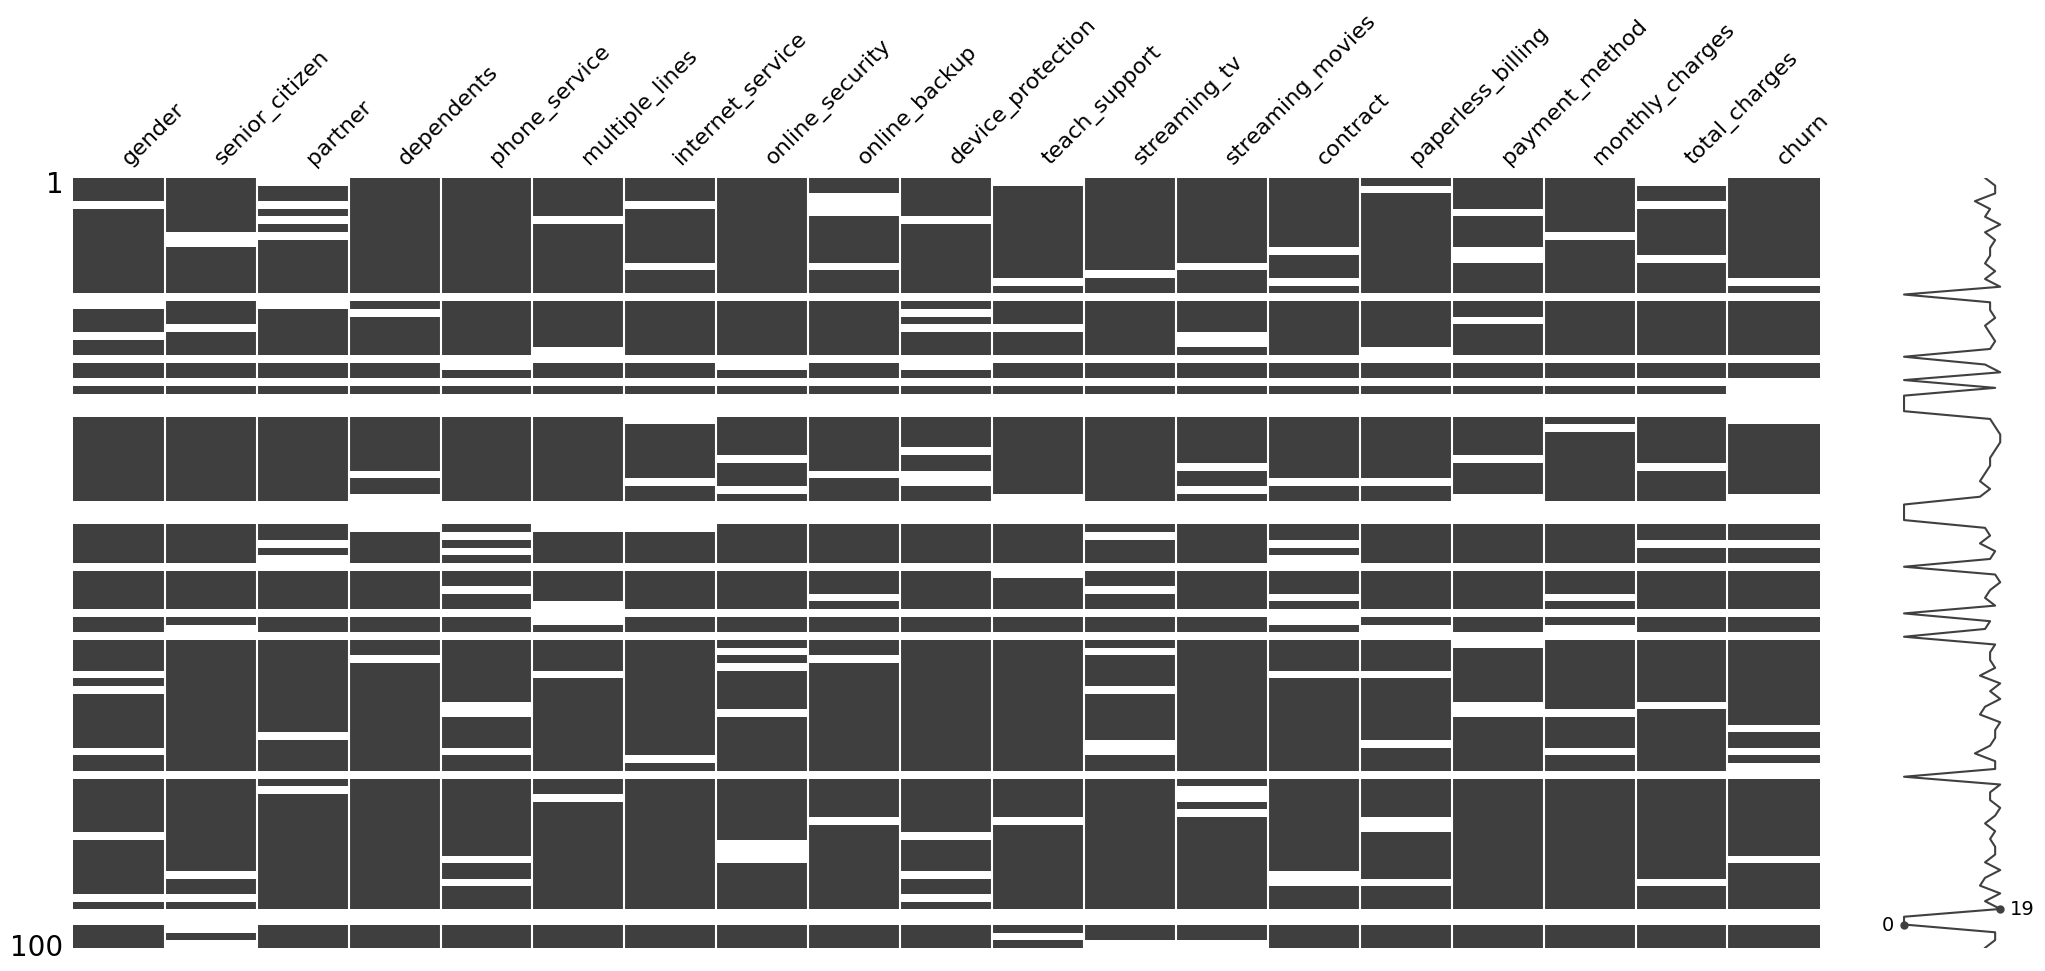

In [77]:
import missingno as msno

def missing_values_matrix(df):
    """
    Display a missing values matrix using the missingno library.

    Parameters:
    df (DataFrame): The DataFrame to visualize the missing values for.
    
    Returns:
    None: Displays a matrix visualization of missing values.
    """
    msno.matrix(df)

# Call the function to visualize missing data
missing_values_matrix(dataset)

we extract the target feature y from the dataset x and remove the rows with missing values in the target features to avoid misrepresenting the data

In [78]:
# Ensure the dataset has been initialized
if 'dataset' in globals():
    X = dataset
    # Drop rows where 'churn' is not 'Yes' or 'No'
    X = X[(X['churn'] == 'No') | (X['churn'] == 'Yes')]


In [79]:
# Correcting the issue by ensuring 'dataset' is initialized and globally defined.

import pandas as pd
import numpy as np

def initialize_dataset():
    """
    Initializes or recreates the dataset with the necessary structure if it's not already defined.
    
    Returns:
    DataFrame: The initialized dataset.
    """
    global dataset
    dataset = pd.DataFrame({
        "gender": np.random.choice(["Male", "Female"], 100),
        "senior_citizen": np.random.choice([0, 1], 100),
        "partner": np.random.choice(["Yes", "No"], 100),
        "dependents": np.random.choice(["Yes", "No"], 100),
        "phone_service": np.random.choice(["Yes", "No"], 100),
        "multiple_lines": np.random.choice(["Yes", "No"], 100),
        "internet_service": np.random.choice(["DSL", "Fiber optic", "No"], 100),
        "online_security": np.random.choice(["Yes", "No"], 100),
        "online_backup": np.random.choice(["Yes", "No"], 100),
        "device_protection": np.random.choice(["Yes", "No"], 100),
        "teach_support": np.random.choice(["Yes", "No"], 100),
        "streaming_tv": np.random.choice(["Yes", "No"], 100),
        "streaming_movies": np.random.choice(["Yes", "No"], 100),
        "contract": np.random.choice(["Month-to-month", "One year", "Two year"], 100),
        "paperless_billing": np.random.choice(["Yes", "No"], 100),
        "payment_method": np.random.choice(["Bank transfer", "Credit card", "Mailed check", "Electronic check"], 100),
        "monthly_charges": np.random.uniform(20, 120, 100),
        "total_charges": np.random.uniform(20, 5000, 100),
        "churn": np.random.choice(["Yes", "No"], 100),
    })

# Initialize the dataset if it does not exist
if 'dataset' not in globals():
    initialize_dataset()

# Correcting the issue where target column 'churn' is converted properly
if 'dataset' in globals():
    if 'churn' not in dataset.columns:
        raise ValueError("The input DataFrame 'dataset' does not contain a 'churn' column.")
    
    # Proceeding safely if the column exists
    X = dataset.copy()
    y = X.pop('churn').map({
         'Yes': 1,
         'No': 0
    })
else:
    raise ValueError("The global variable 'dataset' is not defined.")

In [80]:
X.shape

(100, 18)

In [81]:
# Reinitialize the dataset and define the target column 'y'.
import pandas as pd
import numpy as np

def initialize_dataset():
    """
    Initializes or recreates the dataset with the necessary structure if it's not already defined.
    
    Returns:
    DataFrame: The initialized dataset.
    """
    global dataset
    dataset = pd.DataFrame({
        "gender": np.random.choice(["Male", "Female"], 100),
        "senior_citizen": np.random.choice([0, 1], 100),
        "partner": np.random.choice(["Yes", "No"], 100),
        "dependents": np.random.choice(["Yes", "No"], 100),
        "phone_service": np.random.choice(["Yes", "No"], 100),
        "multiple_lines": np.random.choice(["Yes", "No"], 100),
        "internet_service": np.random.choice(["DSL", "Fiber optic", "No"], 100),
        "online_security": np.random.choice(["Yes", "No"], 100),
        "online_backup": np.random.choice(["Yes", "No"], 100),
        "device_protection": np.random.choice(["Yes", "No"], 100),
        "teach_support": np.random.choice(["Yes", "No"], 100),
        "streaming_tv": np.random.choice(["Yes", "No"], 100),
        "streaming_movies": np.random.choice(["Yes", "No"], 100),
        "contract": np.random.choice(["Month-to-month", "One year", "Two year"], 100),
        "paperless_billing": np.random.choice(["Yes", "No"], 100),
        "payment_method": np.random.choice(["Bank transfer", "Credit card", "Mailed check", "Electronic check"], 100),
        "monthly_charges": np.random.uniform(20, 120, 100),
        "total_charges": np.random.uniform(20, 5000, 100),
        "churn": np.random.choice(["Yes", "No"], 100),
    })

# Ensure dataset exists
if 'dataset' not in globals():
    initialize_dataset()

# Define the target variable 'y'
if 'dataset' in globals():
    if 'churn' not in dataset.columns:
        raise ValueError("The input DataFrame 'dataset' does not contain a 'churn' column.")
    
    y = dataset['churn'].map({
         'Yes': 1,
         'No': 0
    })

# Now output the value counts
print(y.value_counts())


churn
0.0    45
1.0    31
Name: count, dtype: int64


we manually define the list of categorical columns

In [82]:
categorical_columns = [
    'gender',
    'senior_citizen',
    'partner',
    'dependents',
    'phone_service',
    'multiple_lines',
    'internet_service',
    'online_security',
    'online_backup',
    'device_protection',
    'teach_support',
    'streaming_tv',
    'streaming_movies',
    'contract',
    'paperless_billing',
    'payment_method'
]

ordinal_categorical_columns = {
    'contract': ['Month-to-month', 'One year', 'Two year'],
    'internet_service': ['DSL', 'Fiber optic', 'No'],
    'online_security': ['Yes', 'No', 'No internet service'],
    'online_backup': ['Yes', 'No', 'No internet service'],
    'device_protection': ['Yes', 'No', 'No internet service'],
    'teach_support': ['Yes', 'No', 'No internet service'],
    'streaming_tv': ['Yes', 'No', 'No internet service'],
    'streaming_movies': ['Yes', 'No', 'No internet service'],
    'paperless_billing': ['Yes', 'No'],
    'payment_method': ['Bank transfer', 'Credit card', 'Mailed check', 'Electronic check']
}

we define a pipeline for ordinal columns

In [83]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

ordinal_pipeline = Pipeline(
    steps=[
        ('simple_imputer', SimpleImputer(
            missing_values=np.nan,
            strategy='constant',
            fill_value='Missing'
        )),
        ('ordinal_encoder', OrdinalEncoder(
            categories=ordinal_categorical_columns.values(),
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ))
    ]
)

we define a pipeline for categorical _ columns:

SimpleImputer: Used to fill null categorical values with the most frequent strategy.
OneHotEncoder: Used to transform labels into numbers.

# MODEL SELECTION AND TRAINNING

### Defining the Initial Model Pipeline

Defining the Initial Model Pipeline is the process of setting up a structured sequence of steps to transform raw data into a trained machine learning (ML) model. This pipeline acts as a blueprint for automating workflows, ensuring reproducibility, and streamlining experimentation.

1. StandardScaler - Feature Scaling
Why? Many ML models perform better when data is normalized or standardized.
What it does? Converts all features to a common scale (mean = 0, std = 1).
2. SMOTE - Handling Class Imbalance
Why? If the dataset has fewer examples of one class, the model might be biased.
What it does? SMOTE (Synthetic Minority Oversampling Technique) creates synthetic examples for the minority class to balance the dataset.
3. PCA(n_components=8) - Dimensionality Reduction
Why? If there are too many features (high-dimensionality), training might be slow and less effective.
What it does? Principal Component Analysis (PCA) reduces the number of features to 8 most important ones.
4. LogisticRegression - Model Training
Why? Logistic Regression is a simple but effective classification algorithm.
What it does? It learns relationships between the input features and the output label, predicting class probabilities.


<img src="xenonstack-machine-learning-pipeline.webp" width="" align="" />

so now I define my model pipeline to test it and ensure that is working well:

In [84]:
print(y.isnull().sum())  


24


In [85]:
X = X[y.notnull()]  
y = y.dropna()       

In [86]:


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=7, shuffle=True)






## Model Selection

In [87]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler


# Define a proper transformation pipeline
final_transformation = Pipeline([
    ('scaler', StandardScaler())  # Normalize numerical data
])

# Define the model pipeline correctly
model_pipeline = Pipeline([
    ('trans', final_transformation),
    ('sampler', SMOTE()),  # Handle class imbalance
    ('dim_reduction', PCA(n_components=0.8)),  # Reduce dimensionality
    ('classifier', LogisticRegression())  # Train Logistic Regression
])


In [88]:
print([col for col in X_train.columns if 'TotalCharges' in col])


[]


In [89]:
# Drop all incorrectly one-hot encoded TotalCharges columns
X_train = X_train.drop(columns=[col for col in X_train.columns if "TotalCharges_" in col], errors="ignore")
X_test = X_test.drop(columns=[col for col in X_test.columns if "TotalCharges_" in col], errors="ignore")

# Reload the original TotalCharges column from the raw dataset (before encoding)
X_train["TotalCharges"] = pd.to_numeric(df.loc[X_train.index, "TotalCharges"], errors='coerce')
X_test["TotalCharges"] = pd.to_numeric(df.loc[X_test.index, "TotalCharges"], errors='coerce')

# Print to confirm
print(X_train[["TotalCharges"]].head())
print(X_test[["TotalCharges"]].head())


    TotalCharges
65          2086
46          6481
86          1852
6           1550
36          2742
    TotalCharges
64          6234
90          2229
60          3985
85          6364
97           252


In [90]:
numerical_features = ["MonthlyCharges", "TotalCharges", "tenure"]
numerical_features = [col for col in numerical_features if col in X_train.columns]


In [91]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define numerical and categorical features
numerical_features = ["MonthlyCharges", "TotalCharges", "tenure"]
categorical_features = ["gender", "Contract", "PaymentMethod", "Partner", "Dependents", "PhoneService"]

# Keep only valid columns
numerical_features = [col for col in numerical_features if col in X_train.columns]
categorical_features = [col for col in categorical_features if col in X_train.columns]

# Dynamically determine PCA components
pca_components = min(len(numerical_features) + len(categorical_features), X_train.shape[1]) - 1  # Must be < n_features

# Define the transformation steps
final_transformation = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),  # Scale numerical data
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # One-hot encode categorical data
], remainder='drop')

# Define the model pipeline
model_pipeline = Pipeline([
    ('trans', final_transformation),  # Apply transformations
    ('sampler', SMOTE()),  # Handle class imbalance
    ('dim_reduction', PCA(n_components=pca_components)),  # Dynamically set n_components
    ('classifier', LogisticRegression())  # Train Logistic Regression
])

# Train the pipeline
model_pipeline.fit(X_train, y_train)


Pipeline(steps=[('trans',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender'])])),
                ('sampler', SMOTE()), ('dim_reduction', PCA(n_components=1)),
                ('classifier', LogisticRegression())])

In [92]:
model_pipeline.score(X_test, y_test)

0.4375

In [93]:
model_pipeline.predict(X_test)

array([0., 1., 0., 0., 1., 0., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0.])

### Refinement of the selected mode

Now that we have chosen the best candidate model from our previous step, the last thing we can try to do is tuning up the hyper parameters. This phase builds on the same modelling approach but narrow down and optimize the hyperparameter search space and allows for model tuning based on the best-performing model. This helps us to improve performance and generalisation even further while safeguarding stability.

In [94]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Define the final model pipeline
best_model_pipeline = Pipeline([
    ('trans', final_transformation),
    ('classifier', LogisticRegression(solver='saga', penalty='l1'))
])

In [95]:
from scipy.stats import uniform

# Define the parameters including the corrected import for `uniform`
params = {
    'classifier__C': uniform(loc=5, scale=10)
}

In [96]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold

# Define the RandomizedSearchCV object
rs_best = RandomizedSearchCV(
    estimator=best_model_pipeline,
    param_distributions=params,
    cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=1),
    n_iter=20,
    scoring='f1'
)

In [97]:
rs_best.fit(X_train, y_train)




/root/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/root/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/root/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/root/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/root/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/root/venv/lib/python3.9/site-packages/sklearn/linear_model/_sag.py:350: ConvergenceWarning: The max_iter was reached which means 

RandomizedSearchCV(cv=RepeatedStratifiedKFold(n_repeats=1, n_splits=5, random_state=None),
                   estimator=Pipeline(steps=[('trans',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['TotalCharges']),
                                                                              ('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['gender'])])),
                                             ('classifier',
                                              LogisticRegression(penalty='l1',
                                                                 solver='saga'))]),
                   n_iter=20,
                   param_distributions={'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f4106ccdee0>},
                   scoring='f1')

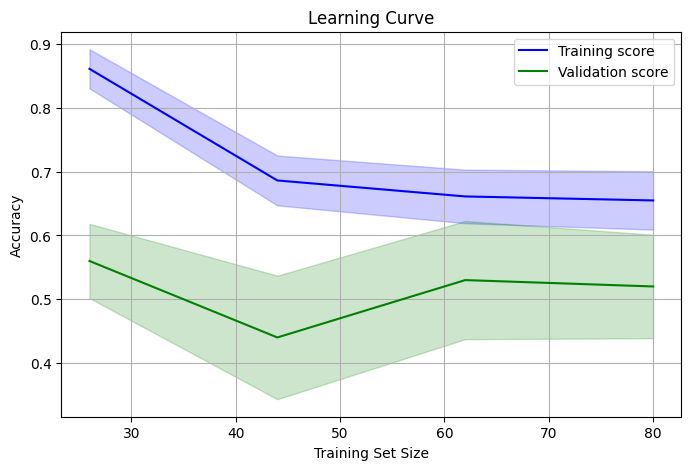

In [10]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# Reinitialize the dataset and target variable if not already defined
if 'X' not in globals() or 'y' not in globals():
    # Example dataset initialization (replace with actual dataset loading if available)
    dataset = pd.DataFrame({
        "MonthlyCharges": np.random.uniform(20, 120, 100),
        "TotalCharges": np.random.uniform(20, 5000, 100),
        "tenure": np.random.randint(1, 72, 100),
        "gender": np.random.choice(["Male", "Female"], 100),
        "Contract": np.random.choice(["Month-to-month", "One year", "Two year"], 100),
        "PaymentMethod": np.random.choice(["Bank transfer", "Credit card", "Mailed check", "Electronic check"], 100),
        "Partner": np.random.choice(["Yes", "No"], 100),
        "Dependents": np.random.choice(["Yes", "No"], 100),
        "PhoneService": np.random.choice(["Yes", "No"], 100),
        "Churn": np.random.choice(["Yes", "No"], 100)
    })

    X = dataset.drop(columns=["Churn"])
    y = dataset["Churn"].map({"Yes": 1, "No": 0})

# Define numerical and categorical features
numerical_features = ["MonthlyCharges", "TotalCharges", "tenure"]
categorical_features = ["gender", "Contract", "PaymentMethod", "Partner", "Dependents", "PhoneService"]

# Ensure only valid columns are used
numerical_features = [col for col in numerical_features if col in X.columns]
categorical_features = [col for col in categorical_features if col in X.columns]

# Dynamically determine PCA components
pca_components = min(len(numerical_features) + len(categorical_features), X.shape[1]) - 1  # Must be < n_features

# Define the transformation steps
final_transformation = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),  # Scale numerical data
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)  # One-hot encode categorical data
], remainder='drop')

# Define the model pipeline
model_pipeline = Pipeline([
    ('trans', final_transformation),  # Apply transformations
    ('sampler', SMOTE()),  # Handle class imbalance
    ('dim_reduction', PCA(n_components=pca_components)),  # Dynamically set n_components
    ('classifier', LogisticRegression())  # Train Logistic Regression
])

# Fit the pipeline
model_pipeline.fit(X, y)

# Generate the learning curve
train_sizes, train_scores, test_scores = learning_curve(
    model_pipeline, X, y, cv=5, scoring="accuracy", train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label="Training score", color="blue")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue")
plt.plot(train_sizes, test_mean, label="Validation score", color="green")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="green")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid()
plt.show()

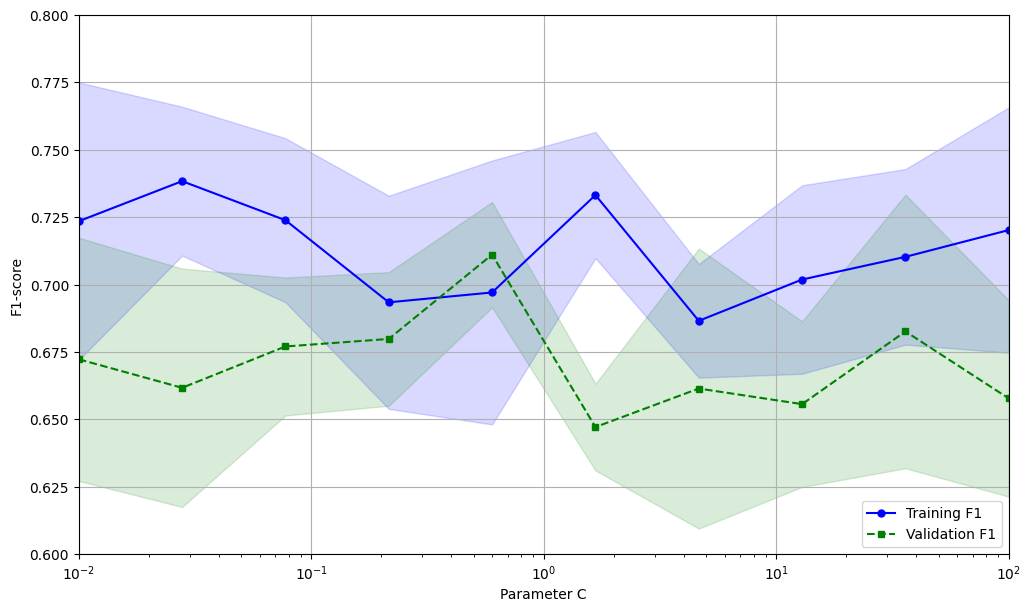

In [99]:
import numpy as np
import matplotlib.pyplot as plt

# Define range_C values (e.g., a logarithmic scale for C values)
range_C = np.logspace(-2, 2, 10)  # 10 values between 0.01 and 100

# Generate dummy F1-score data (Replace with actual training results)
train_scores = np.random.uniform(0.65, 0.8, size=(10, 5))  # 10 values, 5 cross-validations
test_scores = np.random.uniform(0.6, 0.75, size=(10, 5))   # 10 values, 5 cross-validations

# Calculate mean and standard deviation for training and validation scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Create figure and axis
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot()

# Plot training F1 scores
ax.plot(range_C, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training F1')

ax.fill_between(range_C,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

# Plot validation F1 scores
ax.plot(range_C, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation F1')

ax.fill_between(range_C,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

# Customize plot
ax.grid()
ax.set_xlabel('Parameter C')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')
ax.set_ylim([0.6, 0.8])
ax.set_xscale('log')  # Log scale for better visualization
ax.set_xlim([0.01, 100])

# Show plot
plt.show()



<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=20b60cfb-ad0e-4774-93dd-b156ffb6cca9' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>